In [8]:
import numpy as np
import numpy.testing as npt

from scipy import stats
from scipy.stats import t,ttest_ind
from scipy.stats import f
from scipy.stats import f_oneway
from scipy.stats import pearsonr

import statsmodels.api as sm
from statsmodels.regression._prediction import get_prediction
from statsmodels.stats.outliers_influence import OLSInfluence,MLEInfluence
from statsmodels.graphics.gofplots import qqplot_2samples,ProbPlot,qqplot
import pandas as pd
from patsy import dmatrices
from numpy.testing import assert_almost_equal, assert_allclose
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import os

# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,getEigvals

In [9]:
path = os.path.join(os.getcwd(), 'DataSet', 'Table9_4_UnstandardizedRegressor.txt')
df = pd.read_csv(path)

In [10]:
df = pd.read_csv(path)
#print(df.columns.values)
dfX = df.loc[:,['Xi1', 'Xi2', 'Xi3', 'Xi4', 'Xi5', 'Xi6']]
#print(dfX.columns)

In [11]:
#Method 2: Pandas method
corr = dfX.corr(method='pearson')
tableDispFormatt('Correlations Matrix')
print(corr)

=============================== Correlations Matrix ========================================
          Xi1       Xi2       Xi3       Xi4       Xi5       Xi6
Xi1  1.000000  0.052307 -0.343382 -0.497611  0.417297 -0.192099
Xi2  0.052307  1.000000 -0.431595 -0.370696  0.484550 -0.316740
Xi3 -0.343382 -0.431595  1.000000 -0.355121 -0.505158  0.494379
Xi4 -0.497611 -0.370696 -0.355121  1.000000 -0.214554 -0.086906
Xi5  0.417297  0.484550 -0.505158 -0.214554  1.000000 -0.122954
Xi6 -0.192099 -0.316740  0.494379 -0.086906 -0.122954  1.000000


<Axes: >

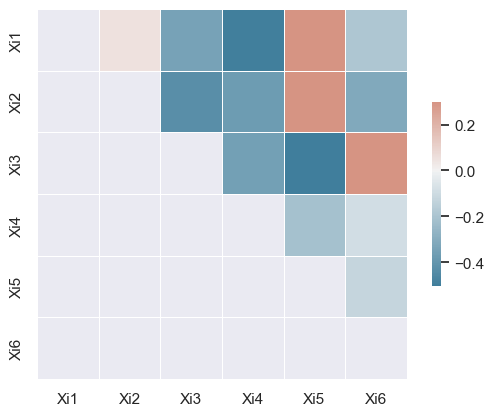

In [12]:
# Prepare Heat Map
mask = np.tril(np.ones_like(corr, dtype=int))
'''
style must be one of white, dark, whitegrid, darkgrid, ticks
'''
sns.set_theme(style="dark")
# sns.set_theme(style="whitegrid")
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [13]:
'''
Correlation Matrix Result analys
'''
ret = getCorrelation(data_frame = dfX ,CorrelationsThreshold = 0.9)
if ret.empty == False:
    plt.show()
    
# Step 2: Calculate VIFS:
tableDispFormatt('Get VIF')
ret = get_variance_inflation_factors(dfX)
print(ret)

=============================== Correlation between groups =================================
       between      Corr      pVal
0   [Xi1, Xi2]  0.052307  0.871745
1   [Xi1, Xi3] -0.343382  0.274487
2   [Xi1, Xi4] -0.497611  0.099727
3   [Xi1, Xi5]  0.417297  0.177121
4   [Xi1, Xi6] -0.192099  0.549757
5   [Xi2, Xi3] -0.431595  0.161224
6   [Xi2, Xi4] -0.370696  0.235530
7   [Xi2, Xi5]  0.484550  0.110386
8   [Xi2, Xi6] -0.316740  0.315817
9   [Xi3, Xi4] -0.355121  0.257317
10  [Xi3, Xi5] -0.505158  0.093893
11  [Xi3, Xi6]  0.494379  0.102297
12  [Xi4, Xi5] -0.214554  0.503090
13  [Xi4, Xi6] -0.086906  0.788270
14  [Xi5, Xi6] -0.122954  0.703435
=============================== Check if High Correlation Exist between groups =============
None of the pairwise correlations Rij are suspiciously large
=============================== Get VIF ====================================================
const    1855.912861
Xi1       182.051943
Xi2       161.361942
Xi3       266.263648
Xi4       297.71